In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread("book.jpg")
if img is None:
 print("Image not loaded. Check the file.")
else:
 print("Image loaded successfully.")

Image loaded successfully.


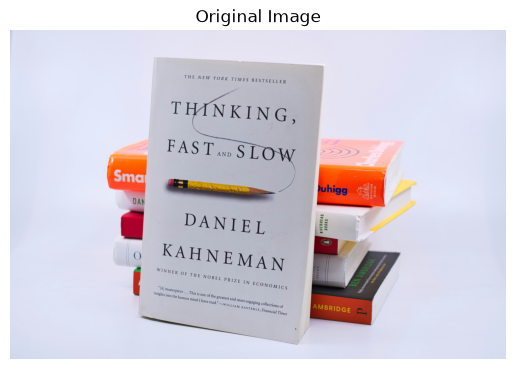

In [15]:
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [16]:
height, width = rgb.shape[:2]
print("Height:", height)
print("Width:", width)

Height: 3264
Width: 4928


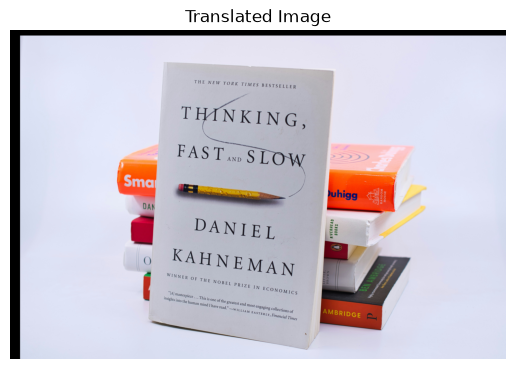

In [17]:
M = np.float32([
 [1, 0, 100],
 [0, 1, 50]
])
translated = cv2.warpAffine(
 rgb,
 M,
 (width, height)
)
plt.imshow(translated)
plt.title("Translated Image")
plt.axis("off")
plt.show()

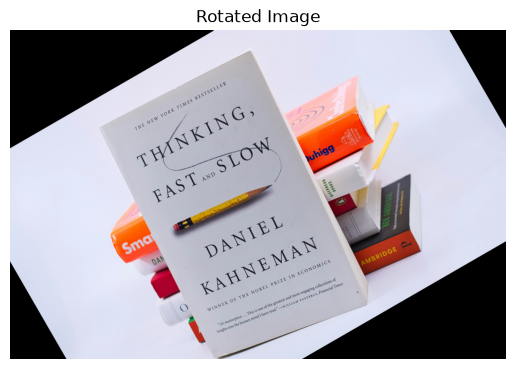

In [18]:
center = (width // 2, height // 2)
rotation_matrix = cv2.getRotationMatrix2D(
 center,
 30,
 1.0
)
rotated = cv2.warpAffine(
 rgb,
 rotation_matrix,
 (width, height)
)
plt.imshow(rotated)
plt.title("Rotated Image")
plt.axis("off")
plt.show()


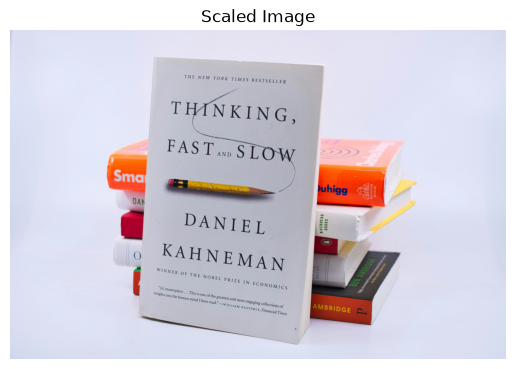

In [19]:
scaled = cv2.resize(
 rgb,
 None,
 fx=0.75,
 fy=0.75,
 interpolation=cv2.INTER_AREA
)
plt.imshow(scaled)
plt.title("Scaled Image")
plt.axis("off")
plt.show()

In [20]:
aspect_ratio = width / height
print("Aspect Ratio:", aspect_ratio)

Aspect Ratio: 1.5098039215686274


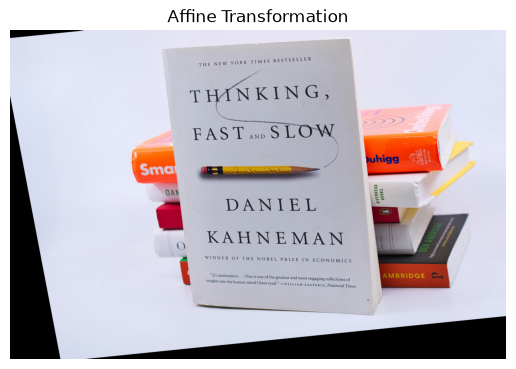

In [21]:
src_points = np.float32([
 [200, 200],
 [1100, 170],
 [180, 850]
])
dst_points = np.float32([
 [150, 260],
 [1130, 130],
 [250, 900]
])
affine_matrix = cv2.getAffineTransform(
 src_points,
 dst_points
)
affine = cv2.warpAffine(
 rgb,
 affine_matrix,
 (width, height)
)
plt.imshow(affine)
plt.title("Affine Transformation")
plt.axis("off")
plt.show()

In [35]:
src = np.float32([
    [1380, 260],   # top-left
    [3050, 320],   # top-right[cite: 1, 2]
    [1230, 3070],  # bottom-left[cite: 1, 2]
    [3000, 2870]   # bottom-right[cite: 1, 2]
])

output_width = 800
output_height = 1200

dst = np.float32([
    [0, 0],
    [output_width - 1, 0],
    [0, output_height - 1],
    [output_width - 1, output_height - 1]
])

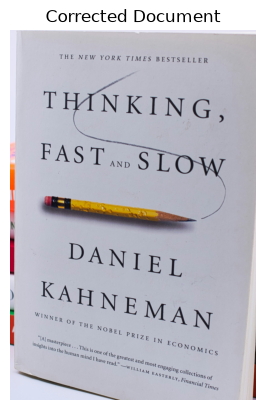

In [36]:
matrix = cv2.getPerspectiveTransform(
 src,
 dst
)
corrected = cv2.warpPerspective(
 rgb,
 matrix,
 (output_width, output_height)
)
plt.imshow(corrected)
plt.title("Corrected Document")
plt.axis("off")
plt.show()


In [40]:
plt.imsave(
 "corrected_document.jpg",
 corrected
)
print("Corrected document saved.")

Corrected document saved.
